# Importing libraries

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Natural Language Processing (NLP) libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Text analysis libraries
from textblob import TextBlob
from wordcloud import WordCloud

# NLP models
import spacy

# Disable pandas chained assignment warning
pd.options.mode.chained_assignment = None

# Other Libraries
from google.colab import files
from IPython.display import display
import string
from nltk.sentiment import SentimentIntensityAnalyzer
from matplotlib import pyplot as plt
#from sklearn.model_selection
#import GridSearchCVfrom sklearn.model_selection
#import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



# Loading data

In [ ]:
# Upload the CSV file
uploaded = files.upload()

# Read the uploaded CSV file into a DataFrame
full_df = pd.read_csv("McDonald_s_Reviews.csv", encoding='latin-1')

# Display the entire DataFrame in table format
display(full_df)


Saving McDonald_s_Reviews.csv to McDonald_s_Reviews.csv


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star
...,...,...,...,...,...,...,...,...,...,...
33391,33392,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",4 years ago,They treated me very badly.,1 star
33392,33393,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,The service is very good,5 stars
33393,33394,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",a year ago,To remove hunger is enough,4 stars
33394,33395,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.810000,-80.189098,"2,810",5 years ago,"It's good, but lately it has become very expen...",5 stars


# Initial Exploratory Data Analysis

Information about the data set

In [ ]:
# Display basic information about the DataFrame
print("Basic information about the DataFrame:")
print(full_df.info())

Basic information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  object 
 2   category       33396 non-null  object 
 3   store_address  33396 non-null  object 
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  object 
 7   review_time    33396 non-null  object 
 8   review         33396 non-null  object 
 9   rating         33396 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 2.5+ MB
None


Distribution of Ratings

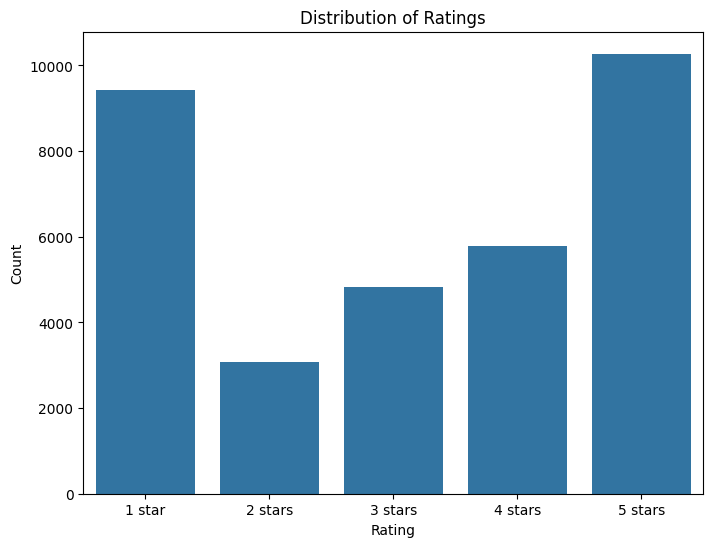

In [ ]:
# Plotting Distribution of ratings
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=full_df, order=['1 star', '2 stars', '3 stars', '4 stars', '5 stars'])
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


Finding the review with the maximum length

In [ ]:
#Finding the review with the maximum length in terms of characters.
full_df['review_length'] = full_df['review'].apply(len)
max_length_review = full_df.iloc[full_df['review_length'].idxmax()]['review']
print(max_length_review)


I want to apologize to anyone that I recommended this particular McDonald's to in the past.
This was the restaurant that I used to recommend to tourists when they were looking for a fast place to eat that was away from the Disney parks, but still close enough to get back to the parks quickly. At that time, it was worth it. The menu was cheap (or at least what you know to expect from a international chain) and, since it's a chain, you know what the food is gong to be like.
So, let's look at what you need to do if you are a member of a chain of restaurants. You need to set yourself apart with your service. This WAS the reason I used to recommend this restaurant. Sadly, I don't think they care anymore. The last time we went, half of the kiosks weren't working. One of the three that was, didn't print receipts. (This plays a part into why the service was so atrocious. Actually there was a lot that played into it.) Now, if you've gone to McDonald's at all recently, you know you pick your foo

# **Preprocessing**

### Handling Missing Values

In [ ]:
# Check for missing values in each column
missing_values = full_df.isnull().sum()

# Display the count of missing values in each column
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
reviewer_id        0
store_name         0
category           0
store_address      0
latitude         660
longitude        660
rating_count       0
review_time        0
review             0
rating             0
review_length      0
dtype: int64


Dropping columns with missing values

In [ ]:
# Drop columns with missing values (NaN)
full_df.dropna(axis=1, inplace=True)

# Print the column namees of the DataFrame to verify that the columns with Null values have been removed
print(full_df.columns)

Index(['reviewer_id', 'store_name', 'category', 'store_address',
       'rating_count', 'review_time', 'review', 'rating', 'review_length'],
      dtype='object')


### Preprocessing Process

In [ ]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')



# Function for text preprocessing
def preprocess_text(text):

    # Tokenization
    tokens = word_tokenize(text)

    # Lowercasing
    tokens = [word.lower() for word in tokens]

    # Remove punctuation and special characters
    table = str.maketrans('', '', string.punctuation)
    tokens = [word.translate(table) for word in tokens]
    tokens = [word for word in tokens if word.isalpha()]

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into a string
    preprocessed_text = ' '.join(tokens)

    return preprocessed_text

# Apply text preprocessing to the 'review' column
full_df['review'] = full_df['review'].apply(preprocess_text)

# Display the preprocessed DataFrame
full_df.head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,reviewer_id,store_name,category,store_address,rating_count,review_time,review,rating,review_length
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States","1,240",3 months ago,look like someone spit food normal transaction...,1 star,259
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States","1,240",5 days ago,mcdonalds far food atmosphere go staff make di...,4 stars,237
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States","1,240",5 days ago,made mobile order got speaker checked line mov...,1 star,415
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States","1,240",a month ago,mc crispy chicken sandwich customer service qu...,5 stars,176
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States","1,240",2 months ago,repeat order time drive thru still manage mess...,1 star,312


# Creating a new seperated data frame

In [ ]:
# Create a new column for the length of each review
full_df['review_length'] = full_df['review'].apply(len)

# Select only the specified columns
data = full_df[['reviewer_id', 'review', 'rating', 'review_length']]

# Set display options to left-align the table content
pd.set_option('colheader_justify', 'left')

# Display the preprocessed DataFrame
data.head()


,reviewer_id,review,rating,review_length
0,1,look like someone spit food normal transaction...,1 star,147
1,2,mcdonalds far food atmosphere go staff make di...,4 stars,138
2,3,made mobile order got speaker checked line mov...,1 star,183
3,4,mc crispy chicken sandwich customer service qu...,5 stars,51
4,5,repeat order time drive thru still manage mess...,1 star,189


# **Sentiment Analysis**

In [ ]:

nltk.download('vader_lexicon')

# Initialize the SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

# Function to perform sentiment analysis
def analyze_sentiment(text):
    # Get sentiment scores using SentimentIntensityAnalyzer
    scores = sid.polarity_scores(text)
    # Return the compound sentiment score
    return scores['compound']

# Apply sentiment analysis to the preprocessed review text
data['sentiment_score'] = data['review'].apply(analyze_sentiment)

# Display the DataFrame with sentiment scores
display(data.head())
display(data.tail())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,reviewer_id,review,rating,review_length,sentiment_score
0,1,look like someone spit food normal transaction...,1 star,147,0.5541
1,2,mcdonalds far food atmosphere go staff make di...,4 stars,138,0.8591
2,3,made mobile order got speaker checked line mov...,1 star,183,-0.2960
3,4,mc crispy chicken sandwich customer service qu...,5 stars,51,0.0000
4,5,repeat order time drive thru still manage mess...,1 star,189,-0.7184


,reviewer_id,review,rating,review_length,sentiment_score
33391,33392,treated badly,1 star,13,-0.4767
33392,33393,service good,5 stars,12,0.4404
33393,33394,remove hunger enough,4 stars,20,-0.2500
33394,33395,good lately become expensive,5 stars,28,0.4404
33395,33396,took good care,5 stars,14,0.7269


Making Sentiment Groups according to the sentimnet score

In [ ]:
# Define thresholds for sentiment scores
positive_threshold = 0.1
negative_threshold = -0.1

# Function to classify sentiment scores into groups
def classify_sentiment(score):
    if score > positive_threshold:
        return "Positive"
    elif score < negative_threshold:
        return "Negative"
    else:
        return "Neutral"

# Apply the function to create a new column for the sentiment groups
data['sentiment_group'] = data['sentiment_score'].apply(classify_sentiment)

display(data.head())

,reviewer_id,review,rating,review_length,sentiment_score,sentiment_group
0,1,look like someone spit food normal transaction...,1 star,147,0.5541,Positive
1,2,mcdonalds far food atmosphere go staff make di...,4 stars,138,0.8591,Positive
2,3,made mobile order got speaker checked line mov...,1 star,183,-0.2960,Negative
3,4,mc crispy chicken sandwich customer service qu...,5 stars,51,0.0000,Neutral
4,5,repeat order time drive thru still manage mess...,1 star,189,-0.7184,Negative


# Classification model and Accuracy

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Your existing code
X = data['review']
y = data['sentiment_group']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize text data
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # Use TF-IDF vectorizer
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Train a classifier (e.g., logistic regression)
classifier = LogisticRegression()
classifier.fit(X_train_tfidf, y_train)

# Predict sentiment on test data
predictions = classifier.predict(X_test_tfidf)

# Evaluate accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)


Accuracy: 0.9035928143712575


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Hyperparameter tuning for classification model:

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Your existing code
# Define the hyperparameters to tune
param_grid = {'C': [0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}

# Perform grid search
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid_search.fit(X_train_tfidf, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Train a classifier with the best hyperparameters
best_classifier = LogisticRegression(**best_params)
best_classifier.fit(X_train_tfidf, y_train)

# Predict sentiment on test data
best_predictions = best_classifier.predict(X_test_tfidf)

# Evaluate accuracy
best_accuracy = accuracy_score(y_test, best_predictions)

print("Best Hyperparameters:", best_params)
print("Accuracy with Best Hyperparameters:", best_accuracy)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best Hyperparameters: {'C': 1, 'penalty': 'l2'}
Accuracy with Best Hyperparameters: 0.9035928143712575


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report:

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Generate classification report
class_report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(class_report)


Confusion Matrix:
[[1337  164  105]
 [  72 1200   90]
 [ 111  102 3499]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.83      0.86      1606
     Neutral       0.82      0.88      0.85      1362
    Positive       0.95      0.94      0.94      3712

    accuracy                           0.90      6680
   macro avg       0.88      0.89      0.88      6680
weighted avg       0.90      0.90      0.90      6680



# **Visualization**

## Distribution of Sentiment Scores

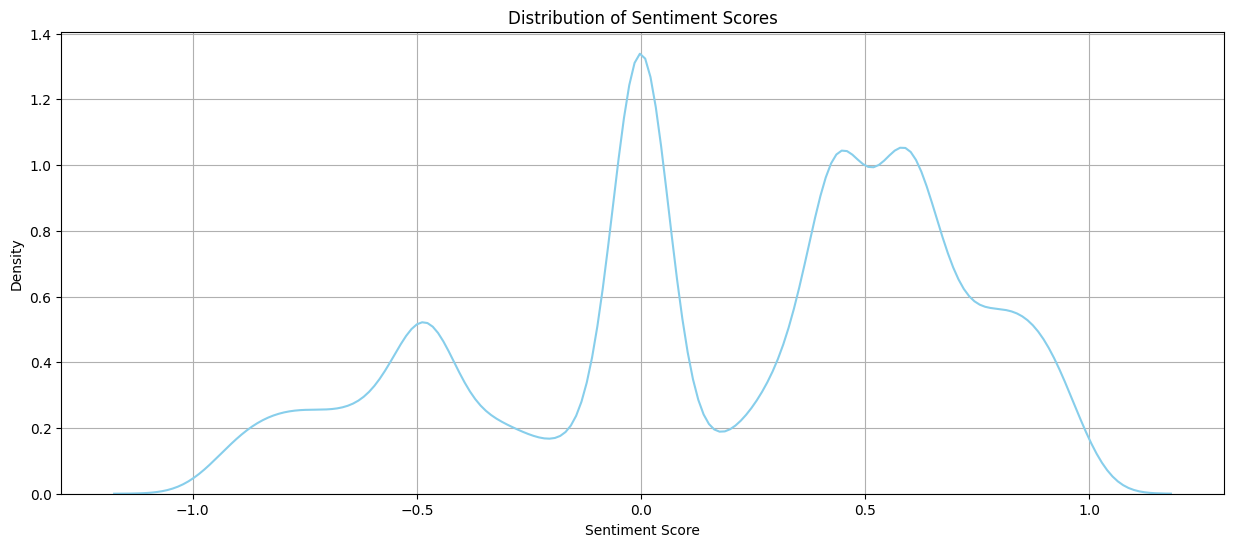

In [ ]:
plt.figure(figsize=(15, 6))

# KDE plot of sentiment scores
sns.kdeplot(data['sentiment_score'], color='skyblue')
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Density')
plt.grid(True)

plt.show()




## Pie charts for the percentages of sentiment groups and ratings

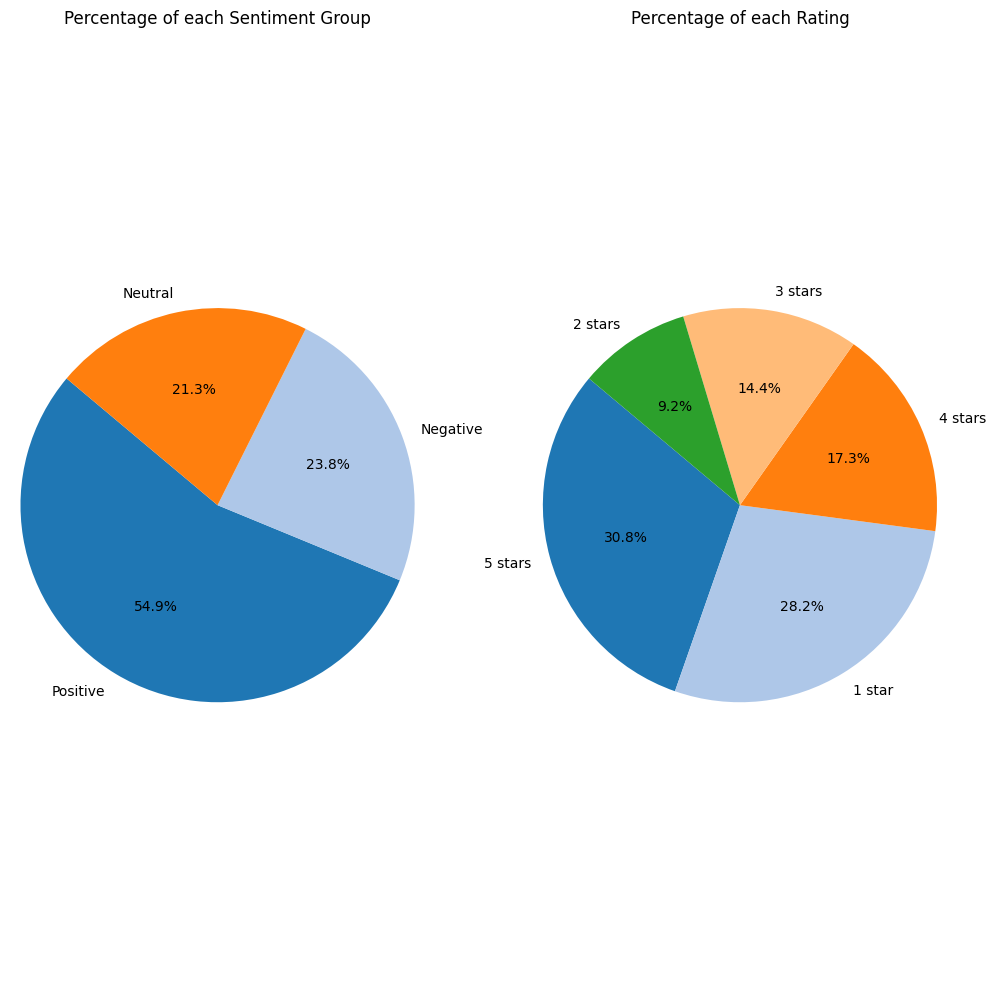

In [ ]:

fig, axs = plt.subplots(1, 2, figsize=(10, 10))

# Pie chart for sentiment_group
sentiment_counts = data['sentiment_group'].value_counts()

axs[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
axs[0].set_title('Percentage of each Sentiment Group')
axs[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Pie chart for ratings
rating_counts = data['rating'].value_counts()
axs[1].pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
axs[1].set_title('Percentage of each Rating')
axs[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## Box plot of sentiment scores by rating

<ipython-input-23-76c9f1a6c705>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='sentiment_score', data=data, palette='viridis')


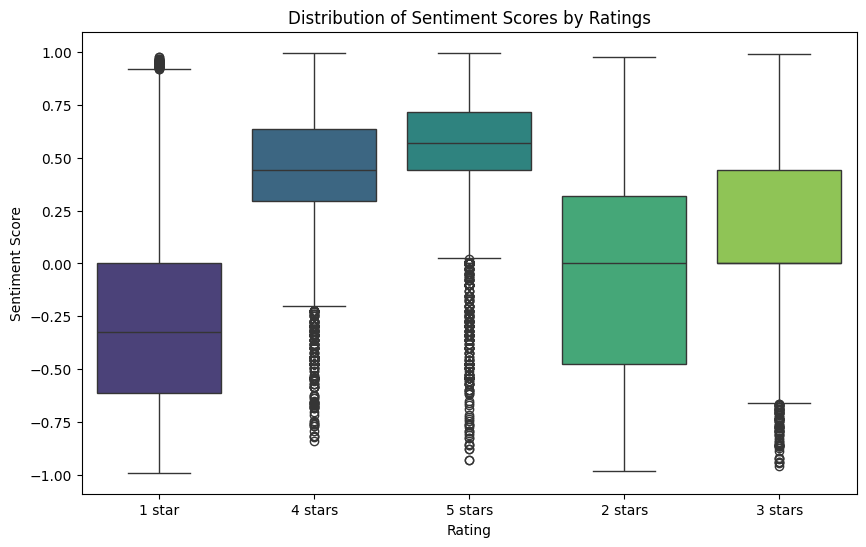

In [ ]:




# Create a box plot of sentiment scores by rating
plt.figure(figsize=(10, 6))
sns.boxplot(x='rating', y='sentiment_score', data=data, palette='viridis')
plt.title('Distribution of Sentiment Scores by Ratings')
plt.xlabel('Rating')
plt.ylabel('Sentiment Score')
plt.show()



## Word clouds for each sentiment group

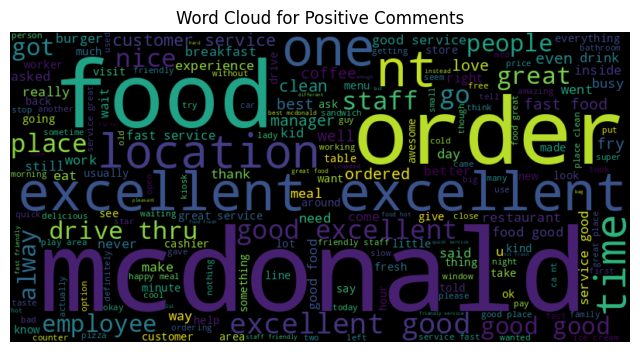

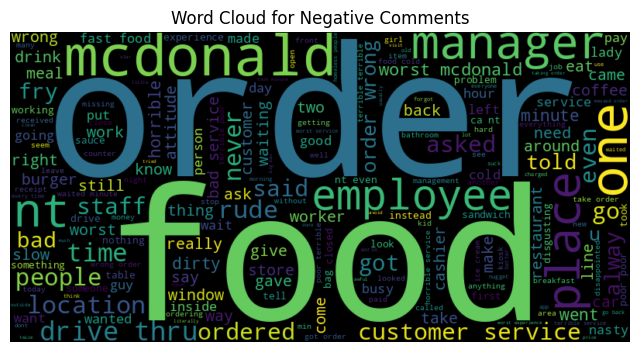

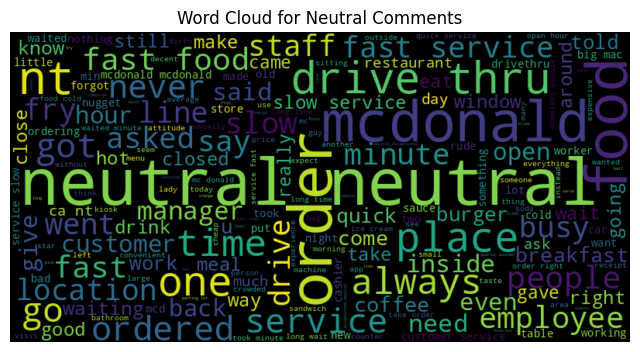

In [ ]:




# Filter data into separate subsets
positive_texts = data[data['sentiment_group'] == 'Positive']['review']
negative_texts = data[data['sentiment_group'] == 'Negative']['review']
neutral_texts = data[data['sentiment_group'] == 'Neutral']['review']



# Generate word clouds for each sentiment group
def generate_word_cloud(texts, title, colormap='oranges',border_color='black', border_width=3):
    wordcloud = WordCloud(width=800, height=400, background_color='black').generate(' '.join(texts))
    plt.figure(figsize=(8, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

generate_word_cloud(positive_texts, 'Word Cloud for Positive Comments')
generate_word_cloud(negative_texts, 'Word Cloud for Negative Comments')
generate_word_cloud(neutral_texts, 'Word Cloud for Neutral Comments')


## Relationship between Review Length and Rating (Colored by Sentiment Group)

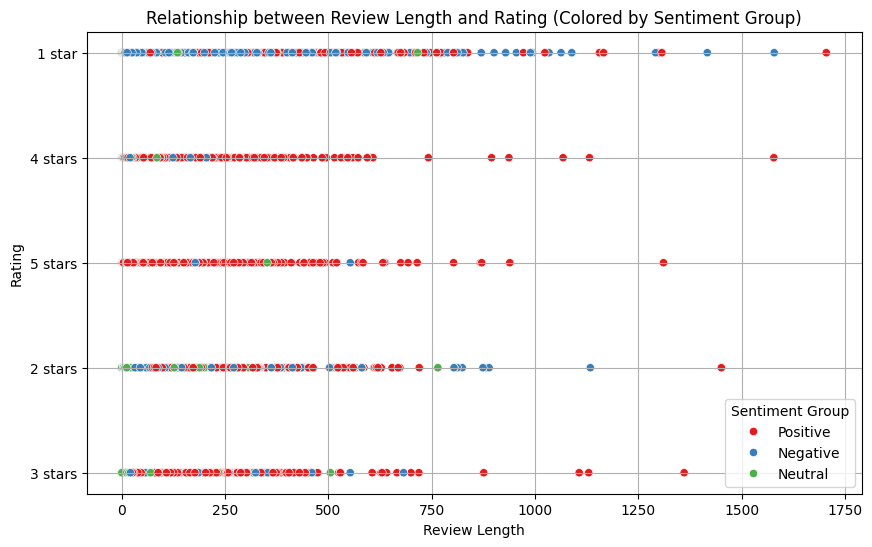

In [ ]:


# Set up the figure and axis
plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(data= data, x='review_length', y='rating', hue='sentiment_group', palette='Set1')

# Add title and labels
plt.title('Relationship between Review Length and Rating (Colored by Sentiment Group)')
plt.xlabel('Review Length')
plt.ylabel('Rating')

# Show the plot
plt.legend(title='Sentiment Group')
plt.grid(True)
plt.show()
